# <center> Импорт библоиотек <center>

*NOTE*: не забудьте соствить список библиотек, необходимых для реализации ваших решений, и представить их в файле `requirements.txt`.

In [1]:
import pickle
import random
import json
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score , accuracy_score
from tqdm import tqdm

# <center> Чтение данных <center>

Тренировчные данные представлены в виде файла в формате JSON. В котором верхенеуровневый ключ -- это номер образца (бакетрии). Каждый словарь по бактериям содержит название штамма и результаты масс-спектрометрического анализа, которые представлены следующими полями: масса к заряду (m/z), время (time), интенсивность пика (Intens.), разрешение (Res.), площадь пика (Area), относительная интенсивность (Rel. Intens.), ширина на полувысоте (FWHM=full width at half-maximum intensity). Каждый штамм будет представлен несколькими бактериями.

In [2]:
with open('/content/train.json', 'rb') as fp:
    train_d = json.load(fp)
train_df = pd.DataFrame(json.loads(train_d)).T
train_df.drop('Bk. Peak', axis=1, inplace=True) # в столбце Bk. Peak нет ничего кроме нулей

Так как тренировочный набор данных не очень большой, дополним его симмулированными данными. Для этого составим дополнительные примеры из существующих. Зададим seed для воспроизводимости результатов.

In [3]:
# для начала орпеделим количестов пиков в масс-спектрах
train_df.loc[:,'n_peak'] = train_df['m/z'].apply(len)

In [4]:
def get_dif(x):
    return max(x) - min(x)

In [5]:
# посмотрим на сколько по количеству строк (пиков) различаются таблицы внутри каждого штамма
peaks_dif = train_df.groupby(['strain']).agg({'n_peak': get_dif})

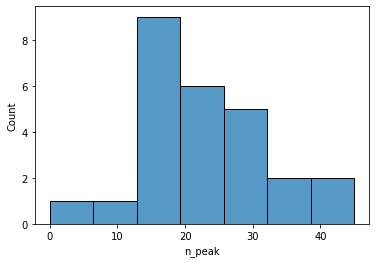

In [6]:
sns.histplot(peaks_dif.n_peak)

In [7]:
# будем использовать среднюю разности для варьирвания числа пиков в сгенерированных данных
MEAN_DIF = int(peaks_dif.n_peak.mean()) 

In [8]:
FEATURES = ['m/z', 'Intens.', 'SN', 'Res.', 'Area', 'Rel. Intens.', 'FWHM']

In [9]:
# генерация медиан и стандартных распределений
median = []
std = []
min = []

for strain in train_df.strain.unique():
    tmp = train_df[train_df.strain == strain] #примеры класса strain
    strain_df = pd.DataFrame()


    for i,sample in enumerate(tmp[FEATURES].values): # strain - матрица фичей для каждого сэмпла
        tmp_i = pd.DataFrame(list(sample)).T
        tmp_i.columns = FEATURES
        strain_df = pd.concat([ strain_df, tmp_i])


    std_stam = []
    min_stam = []
    median_stam = []


    for i in FEATURES:
        min_stam.append(strain_df[i].min())
        std_stam.append(strain_df[i].std())
        median_stam.append(strain_df[i].mean())


    median.append(median_stam)
    std.append(std_stam)
    min.append(min_stam)


median = pd.DataFrame(median, columns=FEATURES)
std = pd.DataFrame(std, columns=FEATURES)
min = pd.DataFrame(min, columns=FEATURES)


std['strain'] = train_df.strain.unique()
median['strain'] = train_df.strain.unique()
min['strain'] = train_df.strain.unique()

In [78]:
def generate_vec(stam: str, features: list, median_values: list, min_values: list, std_values: list, n_peaks: int) -> pd.DataFrame:
  """Функция которая генерирует n_peaks пиков"""
  sample = []
  for i in range(n_peaks):
      vec = []
      for j in range(len(features)):
          vec.append(2*(np.random.rand()-0.5)*std_values[j] + median_values[j])
      sample.append(vec)
  return pd.DataFrame(sample, columns=features)

In [45]:
np.random.seed(1)
train_gen = pd.DataFrame()
N_SAMPLES = 10
id = 0

for strain in tqdm(train_df.strain.unique()):
    tmp = train_df[train_df.strain == strain] #примеры класса strain
    std_strain = tmp['m/z'].apply(len).mean() #среднее количество пиков для класса


    for i in range(N_SAMPLES):
        n = np.random.randint(std_strain + MEAN_DIF)

        med_strain = median[median['strain'] == strain].values[0][:-1]
        features_mean_strain = std[std['strain'] == strain].values[0][:-1]
        min_strain = min[min['strain'] == strain].values[0][:-1]

        df_i = generate_vec(strain, FEATURES, med_strain, min_strain, features_mean_strain, n)
        df_i['id'] = id
        df_i['strain'] = strain
        df_i['n_peak'] = n

        train_gen = pd.concat([train_gen, df_i]) 
        id +=1

100%|██████████| 26/26 [00:01<00:00, 18.69it/s]


In [46]:
train_gen

,m/z,Rel. Intens.,Res.,FWHM,id,strain,n_peak
0,7325.263754,2001.391410,7.482501,958.499251,0,Staphilococcus aureus_12 K457,37
1,4213.497494,1873.557810,9.043846,835.069209,0,Staphilococcus aureus_12 K457,37
2,7073.223044,1980.821123,8.595268,780.644427,0,Staphilococcus aureus_12 K457,37
3,5061.311936,1833.726483,9.924347,926.609127,0,Staphilococcus aureus_12 K457,37
4,5117.537106,1881.695117,12.356723,875.792135,0,Staphilococcus aureus_12 K457,37
...,...,...,...,...,...,...,...
23,6820.522497,1874.290797,10.555531,890.882135,259,Staphilococcus aureus_7 941,28
24,5437.344875,1915.596116,9.775315,635.972929,259,Staphilococcus aureus_7 941,28
25,7471.308986,1916.813330,8.937772,833.182556,259,Staphilococcus aureus_7 941,28
26,7443.886024,1939.258578,9.648902,666.831879,259,Staphilococcus aureus_7 941,28


In [47]:
train_df.drop('time', axis=1, inplace=True)
train_gen = train_gen.groupby(['strain', 'id']).agg(list).reset_index().drop(['id'], axis = 1)
train_gen['n_peak'] = train_gen['n_peak'].apply(len)

KeyError: ignored

In [ ]:
train_df = train_gen

In [48]:
train_df

,strain,m/z,Intens.,SN,Res.,Area,Rel. Intens.,FWHM,n_peak,mz,intens
0,Staphilococcus aureus_12 K457,"[6554.29838437652, 4862.39574197687, 4487.9141...","[3320.057432224192, 2392.6527495419386, -260.6...","[3.1987606982172503, 18.59821541626965, -1.472...","[1065.5560592623544, 700.9888540768848, 1077.4...","[20749.17112737558, 3931.8242514454214, 48892....","[0.1765624402811274, 0.248145905539875, 0.1654...","[8.859386166921986, 4.423060733948791, 9.66047...",11,"[655, 486, 448, 700, 689, 644, 518, 389, 625, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Staphilococcus aureus_11 K817,"[3983.187898230991, 5811.053441793893, 6231.56...","[1635.2041706859573, -28.099368404037477, 3921...","[-10.184844455307754, 29.997531807828228, 14.0...","[639.0237518996782, 1190.7746550612069, 717.25...","[47149.34866929357, 29587.30959395302, 55486.3...","[0.12992661943691228, -0.03099527959703026, -0...","[6.990898823149703, 8.828190400405743, 7.01647...",91,"[398, 581, 623, 650, 425, 680, 676, 468, 350, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Staphilococcus aureus_6 1006,"[5321.838662517276, 6469.140962942747, 3314.15...","[4151.539614024883, 37.185646414340226, -586.7...","[16.424577258539074, 26.15569152798978, 18.610...","[771.8529017942615, 457.1518805990327, 625.887...","[15506.754052673807, 64323.59878380653, 66817....","[0.0393802767744624, 0.20355941196398947, 0.07...","[6.89680712900245, 4.6541591892661085, 5.96412...",19,"[532, 646, 331, 322, 327, 748, 382, 749, 726, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Pseudomonas fluorescence_965,"[5639.667315487875, 3462.832541360299, 5019.32...","[1061.7466525690247, 3197.8096627230707, -1506...","[3.3207968228874325, 11.119825360907244, 13.33...","[454.0099915195477, 890.677502883764, 439.8998...","[103539.67266860735, 86761.88362959314, 109132...","[0.09734365630692123, 0.20905840208000293, 0.0...","[8.251752053419768, 8.111553657673243, 8.10872...",8,"[563, 346, 501, 666, 410, 397, 716, 445]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Pseudomonas fluorescence_965,"[6797.74761935805, 6323.254551692853, 3191.798...","[5782.266925619695, 3151.472730194795, 8031.80...","[7.056810529806021, 5.496929382807988, 11.2543...","[682.6797604049277, 825.6733668996653, 497.256...","[51570.04166621027, 31331.90121193812, 75547.9...","[0.14516242604000062, 0.17027068448021268, 0.1...","[6.89984392314525, 5.700955948818747, 5.121319...",84,"[679, 632, 319, 666, 372, 756, 293, 536, 726, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
2573,Acinetobacter baumani_64,"[7365.60730306947, 3850.9216114974547, 5831.50...","[8912.136418045422, 650.5463659993534, 8066.61...","[-5.780920431171829, 46.793562301708675, 49.77...","[1091.186866929907, 964.881773890736, 1015.998...","[156091.89668627668, -18402.065250106774, 1728...","[0.012126547924143166, 0.18037209146114166, -0...","[8.82140591933892, 12.013023525320499, 13.2837...",18,"[736, 385, 583, 435, 784, 726, 483, 930, 898, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2574,Acinetobacter baumani_73,"[3703.3695592580907, 5376.698555964091, 8136.1...","[8225.397916569837, 6679.001361884097, 9386.39...","[14.797296311991108, 74.51910989291378, 44.177...","[1117.285377007484, 456.8458166129429, 729.806...","[-78801.53699722025, 124940.95926138747, -2315...","[0.19970816270949887, 0.20343605135463833, 0.0...","[12.276813607697019, 5.988053582219466, 9.4284...",56,"[370, 537, 813, 843, 561, 458, 796, 384, 882, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2575,Staphilococcus aureus_15,"[6959.755158004944, 7995.850361266145, 8422.45...","[2378.314102828436, -718.715839132592, 5204.59...","[12.414703013794878, 7.849116140747121, 25.704...","[486.5055753509767, 624.1161051142051, 738.954...","[83817.27047190776, 39564.43019572217, 70200.8...","[0.13934919296924012, 0.24857894978877687, 0.1...","[6.109024424201669, 5.467224832006909

Совместим оригинальных датасет и сгенерированный.

In [49]:
train_df.shape

(2578, 11)

# <center> Обработка данных и генерация признаков<center>

Пример таблицы с данными по масс-спектру для одного образца

In [50]:
example = train_df[FEATURES]\
         .loc[(train_df.strain == 'Staphilococcus aureus_6 1006')].iloc[0]
example = pd.DataFrame(list(example)).T
example.columns = FEATURES

In [51]:
example.head()

,m/z,Rel. Intens.,Res.,FWHM
0,5321.838663,0.039380,771.852902,6.896807
1,6469.140963,0.203559,457.151881,4.654159
2,3314.153705,0.077514,625.887383,5.964128
3,3225.259316,0.213119,1095.557668,5.636606
4,3273.082861,0.117503,892.396023,4.690061


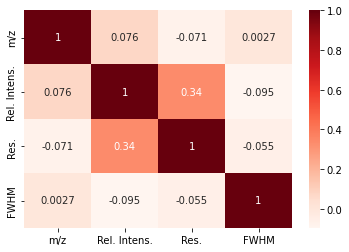

In [52]:
cor = example.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [53]:
## select uncorrelated features
FEATURES = ['m/z', 'Rel. Intens.', 'Res.', 'FWHM']

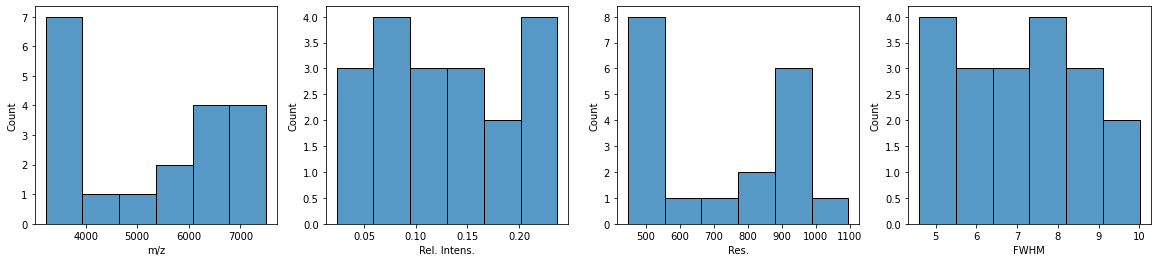

In [54]:
fig, axs = plt.subplots(1,4, figsize=(20, 4))
for features in FEATURES:
    sns.histplot(example[features], ax = axs[FEATURES.index(features)])

Посмотрим на масс-спектры для нескольих примеров

In [55]:
def colors_from_values(values, palette_name):
    values = np.array(values)
    normalized = (values - min(values)) / (max(values) - min(values))
    indices = np.round(normalized * (len(values) - 1)).astype(np.int32)
    palette = sns.color_palette(palette_name, len(values))
    return np.array(palette).take(indices, axis=0)

TypeError: ignored

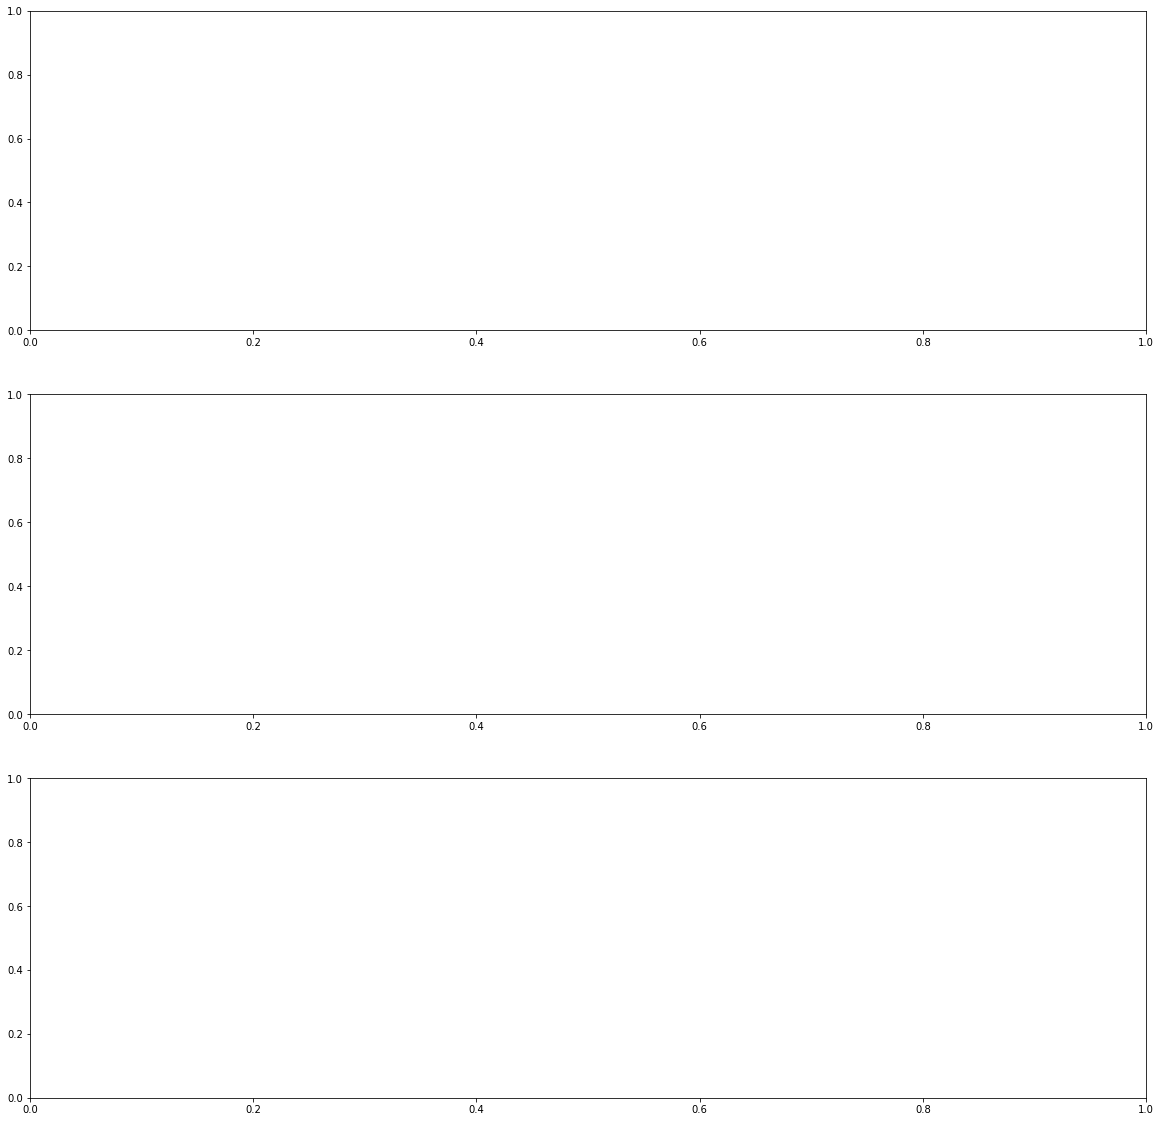

In [56]:
fig, axs = plt.subplots(3,1, figsize=(20,20))
satain = "Acinetobacter baumani_64"
i = 0
for ids in [2,6,8]:
    tmp = train_df.loc[(train_df.strain == strain)].iloc[ids]
    mz = [np.round(x, 2) for x in tmp['m/z']]
    ax =  axs[i]
    sns.barplot(data = tmp, x=mz, y = 'Rel. Intens.', 
                palette=colors_from_values(tmp['Res.'], 'crest'),
                ax = ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    i=i+1

Создаим спектры, которые удобно сравнитвать между собой в виде векторов в фиксированом диапазоне, и уберем необходимость использовать переменную "m/z".

In [57]:
# орпеделим диапазон парамтеров
min(train_df['m/z'].apply(min)), max(train_df['m/z'].apply(max))

SpecificationError: ignored

In [58]:
def create_speactr(mz, intens):
    spec = []
    for i in range(200, 1750):
        if i in mz:
            spec.append(intens[mz.index(i)])
        else:
            spec.append(0)
    return spec

In [59]:
def prepocess_data(data):
    data['mz'] = data['m/z'].apply(lambda x: [int(x_i // 10) for x_i in x])
    data['intens'] = data.apply(lambda d: create_speactr(d['mz'], d['Rel. Intens.']),
                           axis = 1)
    return data

In [60]:
train_df = prepocess_data(train_df)

Перемешаем данные, чтобы классы не шли по порядку

In [61]:
train_df = train_df.sample(frac=1).reset_index(drop=True)

# <center> Обучение моделей <center>

Разобьем выборку на валидационную и тренировочную так, чтобы хотя бы один пример из каждого класса присутствавал
в валидаицонной выборке. После разбиения уберем два класса из тренировочный выборки, чтобы можно было определить их 
как 'new'.

_Note_:  рекомендуем рассмотреть разные вариатны разбиения на тренировочную и валидационную выборку для определения оптиматльных парпамтеров. 

In [62]:
np.random.seed(142)
val_ds = pd.DataFrame()
train_ds = pd.DataFrame()
for strain in train_df.strain.unique():
    n = np.random.randint(1,35)
    ids = random.sample(list(train_df.loc[train_df.strain == strain].index), n)
    val_ds = pd.concat([val_ds, train_df.loc[ids]])
    train_ids = list(set(train_df.loc[train_df.strain == strain].index) - set(ids))
    train_ds = pd.concat([train_ds, train_df.loc[train_ids]])
    

In [63]:
val_ds.shape, train_ds.shape

((478, 11), (2100, 11))

In [64]:
random.seed(111)
val_strain = random.sample(sorted(list(val_ds.strain.unique())), 2)
val_strain

['Acinetobacter baumani_64', 'Pseudomonas fluorescence_965']

In [65]:
train_ds = train_ds[~train_ds.strain.isin(val_strain)]

In [66]:
val_ds.loc[:,'target'] = val_ds.strain
val_ds.loc[val_ds.strain.isin(val_strain),'target'] = 'new'

In [67]:
val_ds[val_ds['target'] == 'new']

,strain,m/z,Intens.,SN,Res.,Area,Rel. Intens.,FWHM,n_peak,mz,intens,target
1971,Pseudomonas fluorescence_965,"[6273.338743413825, 3220.523920038626, 4552.48...","[9058.60409577498, 2720.8243640745222, 3815.39...","[10.825080953783834, 3.7280368999443807, 3.913...","[745.2609578350547, 916.4415309239266, 680.622...","[132134.9674512049, 12136.611924515048, 55314....","[0.18315405764793918, 0.059796389556196886, 0....","[11.379663314799709, 6.124634178967507, 10.599...",86,"[627, 322, 455, 799, 384, 701, 388, 401, 398, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
428,Pseudomonas fluorescence_965,"[3944.359279580156, 2969.1674249351604, 7181.3...","[6732.624435725945, 2573.0601516956367, 7954.4...","[7.677240904772062, 4.602922364352677, 1.37596...","[886.5276601764062, 603.8186405644349, 423.672...","[10121.82929535395, -140.67483105324936, 12869...","[-0.02303944993854419, 0.16777592398020186, 0....","[6.677468793250647, 8.387175430254105, 5.21032...",29,"[394, 296, 718, 308, 378, 395, 402, 354, 787, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
620,Pseudomonas fluorescence_965,"[4700.8479941637315, 3174.254546369789, 3173.9...","[1489.8187721098661, -1401.303897141086, 6347....","[6.965257071217208, 2.8711806537508044, 7.3906...","[685.1901488207892, 465.3341070773886, 916.762...","[64595.70635886206, 71995.0948099111, 105787.3...","[0.19262775466836196, 0.044149210689438924, 0....","[6.433997375501466, 6.302558968988324, 6.54044...",18,"[470, 317, 317, 711, 469, 478, 525, 462, 631, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
346,Pseudomonas fluorescence_965,"[4360.912762389717, 2912.224961187226, 5385.03...","[-215.82978735640154, 845.6762873892567, 1012....","[3.8512701551933812, 12.23104812886408, 9.9849...","[576.5506624385204, 728.0478650684898, 659.802...","[18890.11813026431, 37087.035285107886, 33971....","[0.1994640531961423, 0.1824547931191472, -0.01...","[10.670824004773031, 12.439482023067153, 5.796...",26,"[436, 291, 538, 436, 754, 781, 730, 375, 468, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
1141,Pseudomonas fluorescence_965,"[8094.669596402473, 7066.6426996696155, 5406.1...","[4974.821234687275, 9305.923098816798, 3653.34...","[14.821470834356123, 0.24479414020721446, 0.37...","[921.9739822953748, 772.6909347040969, 418.882...","[-4883.5548663872105, 68393.99348274368, 10300...","[0.16583920489993959, 0.10480129257221117, 0.1...","[4.31154362279002, 8.959008738162439, 11.08125...",7,"[809, 706, 540, 415, 468, 425, 487]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
475,Pseudomonas fluorescence_965,"[5639.667315487875, 3462.832541360299, 5019.32...","[1061.7466525690247, 3197.8096627230707, -1506...","[3.3207968228874325, 11.119825360907244, 13.33...","[454.0099915195477, 890.677502883764, 439.8998...","[103539.67266860735, 86761.88362959314, 109132...","[0.09734365630692123, 0.20905840208000293, 0.0...","[8.251752053419768, 8.111553657673243, 8.10872...",8,"[563, 346, 501, 666, 410, 397, 716, 445]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
1137,Pseudomonas fluorescence_965,"[7066.126864781353, 5974.826357538203, 7993.50...","[7624.677255166858, 8431.40976520838, 7119.493...","[5.409050733908044, 5.042155862298086, 12.6606...","[684.6073991762939, 773.0293007841852, 723.125...","[113405.8993771708, 120830.22954646661, 20299....","[0.08329687382021637, 0.0033986255492249873, 0...","[12.877515894595906, 12.662363864705359, 4.840...",31,"[706, 597, 799, 681, 436, 646, 374, 769, 561, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",new
585,Pseudomonas fluorescence_965,"[6698.005474941254, 2983.450796132134, 6698.74...","[5527.79891943008, 5706.468668782879, 9976.527...","[7.788645832717383, 3.2995521424379888, 1.0233...","[441.7865250847092, 612.8015670648556, 753.744...","[99811.66197595131, 67953.96877709522, 58330.0...","[-0.012722299670554618, 0.042255389244963006, ...","[4.308286797530606, 12.027769018458681, 9.009

In [68]:
val_ds = val_ds.sample(frac=1)
train_ds = train_ds.sample(frac=1)

In [69]:
val_ds.sample(frac=0.5).shape

(239, 12)

In [70]:
val_ds.sample(frac=1).shape

(478, 12)

In [71]:
def make_x(df, col):
    X = []
    for i in df.index:
        row = df.loc[i,col]
        X.append(row)
    return np.array(X)

In [72]:
train_ds.columns

Index(['strain', 'm/z', 'Intens.', 'SN', 'Res.', 'Area', 'Rel. Intens.',
       'FWHM', 'n_peak', 'mz', 'intens'],
      dtype='object')

## Многоклассовый классификатор

In [73]:
X = make_x(train_ds, col='intens')
y = np.array(train_ds['strain'])

In [74]:
model = SVC(gamma='auto', kernel='sigmoid', probability=True)
clf = make_pipeline(StandardScaler(), model)
clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto', kernel='sigmoid', probability=True))])

### проверяем качество модели на валидационной выборке

In [75]:
X_pred = make_x(val_ds, col='intens')

In [76]:
val_ds.loc[:,'class_name'] = clf.predict(X_pred)
val_ds.loc[:,'class_name_proba'] =  np.max(clf.predict_proba(np.array(X_pred)), axis = 1)

In [77]:
# посмотрим на качестов модели, то выделения новых классов
f1_score(val_ds.class_name, val_ds.target, average='macro')

0.19313345554156983

Новые классы будем орпеделять по вероятности определения класса

In [ ]:
plt.hist(val_ds.loc[val_ds.target != 'new'].class_name_proba)
plt.hist(val_ds.loc[val_ds.target == 'new'].class_name_proba)

In [ ]:
val_ds.loc[val_ds.class_name_proba < 0.2,'class_name'] = 'new'

In [ ]:
f1_score(val_ds.class_name, val_ds.target, average='macro')

Как мы видим, после добавления метки 'new' значение метрики возрасло

### сохранение модели

переобучим модель на всей тренировочной выборке, так как мы исключали классы для валидации

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
X = scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)

In [ ]:
catboost_params = {'iterations': 100, 'learning_rate': 0.1,
                   'task_type': 'CPU', 'silent': True,
                   'random_seed': 124, 'depth': 6}
model = CatBoostClassifier(loss_function='MultiClass', **catboost_params)
clf = make_pipeline(model)
clf.fit(X, y)

In [ ]:
!unzip models.zip

In [ ]:
swmPickle = open('models/baseline_clf.pkl', 'wb') 
pickle.dump(clf, swmPickle)   

## Набор бинарных классификатров для каждого тарегта

In [ ]:
X = make_x(train_ds, col='intens')
# X_pred = make_x(val_ds, col='intens')

In [ ]:
# делаем бинарных тарегет для каждого класса
Y = []
for strain in train_ds.strain.unique():
    Y.append(np.array(train_ds.strain == strain))

In [ ]:
# сохраняем порядок классов
class_order = train_ds.strain.unique()

так как негативных примеров для каждого таргета в разы больше положительных, оставим в выборке только примеры в соотношении 3:1 (негативные:положительные)

In [ ]:
res = []
for i,y in enumerate(Y):
    idx_pos = np.where(y ==True)[0]
    idx_neg = np.where(y == False)[0]
    random.shuffle(idx_neg)
    idx = sorted(np.concatenate((idx_pos,idx_neg[:3*len(idx_pos)])))
    
    model = SVC(gamma='scale', probability=True)
    clf = make_pipeline(StandardScaler(), model)
    clf.fit(X[idx,:], y[idx])
    res.append(clf.predict_proba(X_pred)[:,1])

### проверяем качество модели на валидационной выборке

In [ ]:
res = np.array(res).T

In [ ]:
# выбираем класс с наибльшей вероятностью или ставим 0, если веротяность меньше 0.5
class_name = []
for res_i in res:
    if max(res_i) > 0.5:
        class_name.append(class_order[np.where(res_i == max(res_i))[0]].item())
    else:
        class_name.append('new')

In [ ]:
val_ds.loc[:,'class_name'] = class_name

In [ ]:
f1_score(val_ds.class_name, val_ds.target, average='macro')

Данная модель показала самое высокое значение метрики, поэтому берем ее как бейзлайн для данной задачи.

### сохраняем модели

In [ ]:
# переобучаем на полной выборке
res = []
for i,y in enumerate(Y):
    idx_pos = np.where(y ==True)[0]
    idx_neg = np.where(y == False)[0]
    random.shuffle(idx_neg)
    idx = sorted(np.concatenate((idx_pos,idx_neg[:3*len(idx_pos)])))
    
    model = SVC(gamma='scale', probability=True)
    clf = make_pipeline(StandardScaler(), model)
    clf.fit(X[idx,:], y[idx])
    # save model
    strain = class_order[i]
    pickle.dump(clf, open(f'models/baseline_clf_{strain}.pkl', 'wb'))

# <center> Формат решения <center>

В проверяющую систему необходимо отправить код алгоритма, запакованный в ZIP-архив. Архив должен содержать следующие файлы: 
 * solution.py -- файл с кодом запуска решения
 * models/ -- директория, где хранятся обученные модели
 * requiremnts.txt -- необходимые библиотеки для запуска решения
 * \*.py -- вспомогательные модули
 * metadata.json  -- обязательный файл для запуска докера, который содержит название docker image и команду для расчета предсказаний (см. описание задачи)
 
Решение должно быть реализовано в виде программы, которая на вход принимает файл `test.xlsx` и на выходе выдает CSV таблицу (`results.csv`). Файл `results.csv` должен в обязательном порядке содержать поле `class_name`  -- предсказанный класс (название штамма бактерии или метка 'new')